CLASSICAL CNN MODEL USING SDG OPTIMIZER WITH MOMENTUM=0.9

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
# %pip install tensorflow 

In [3]:
import time
import csv
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adagrad
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import load_model
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


In [5]:
# ==========================
# 1️⃣ Load and Preprocess Data
# ==========================
def load_dataset(directory):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=(64, 64))
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), classes

In [ ]:

train_dir = "Brain_Tumor_data/Training"
X, y, class_names = load_dataset(train_dir)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(class_names))

print(f"[INFO] Loaded {len(X)} images across {len(class_names)} classes: {class_names}")

[INFO] Loaded 5712 images across 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:

# ==========================
# 2️⃣ Define CNN Model (with your updated architecture)
# ==========================
def build_cnn(input_shape=(64,64,3), num_classes=4):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Dense Layers
        Flatten(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adagrad(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [13]:

# ==========================
# ⏱️ Custom Callback for Timing
# ==========================
class TimingCallback(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)
        print(f"⏱️ Time for Epoch {epoch + 1}: {epoch_time:.2f} seconds")

In [14]:
# ==========================
# 3️⃣ K-Fold Cross Validation 
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
epoch_time_records = []
training_log = []

os.makedirs("adagrad-logs", exist_ok=True)
os.makedirs("adagrad_models", exist_ok=True)

for train_index, val_index in kf.split(X):
    print(f"\n[INFO] Training Fold {fold_no}...")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y_cat[train_index], y_cat[val_index]

    model = build_cnn((64, 64, 3), len(class_names))
    timing_callback = TimingCallback()

    for epoch in range(30):
        start = time.time()
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=1,
            batch_size=16,
            verbose=1
        )
        end = time.time()
        elapsed = end - start

        train_acc = hist.history['accuracy'][0]
        val_acc = hist.history['val_accuracy'][0]
        train_loss = hist.history['loss'][0]
        val_loss = hist.history['val_loss'][0]
        lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

        # Append all details for CSV
        training_log.append([fold_no, epoch + 1, elapsed, train_acc, val_acc, train_loss, val_loss, lr])

        # The model is no longer saved after every epoch.

    # Save the model only once, after all epochs for the current K-Fold are complete.
    model.save(f"adagrad_models/mlcnn_fold{fold_no}_final.keras")

    fold_no += 1



[INFO] Training Fold 1...


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.6078 - loss: 1.0794 - val_accuracy: 0.2520 - val_loss: 2.1781
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6945 - loss: 0.8213 - val_accuracy: 0.4882 - val_loss: 1.4201
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7063 - loss: 0.7871 - val_accuracy: 0.7559 - val_loss: 0.6020
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7428 - loss: 0.6920 - val_accuracy: 0.7629 - val_loss: 0.6157
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7450 - loss: 0.6958 - val_accuracy: 0.7795 - val_loss: 0.6006
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7717 - loss: 0.6406 - val_accuracy: 0.7900 - val_loss: 0.5371
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7733 - loss: 0.6244 - val_accuracy: 0.7997 - val_loss: 0.5143
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7816 - loss: 0.5977 - val_accuracy: 0.7997 - val_loss: 0.5151
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0

In [16]:
# ===============================
# Save all training details to CSV
# ===============================
csv_path = "adagrad-logs/mlcnn_training_log.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Fold", "Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"])
    writer.writerows(training_log)

print(f"\n💾 Training log saved successfully to: {csv_path}")


💾 Training log saved successfully to: adagrad-logs/mlcnn_training_log.csv


In [17]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,626,314 (6.20 MB)

 Trainable params: 812,644 (3.10 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 812,646 (3.10 MB)

In [18]:
model.save("classical_cnn_Adagrad_complete.keras")
print("[INFO] Final model saved successfully!")

[INFO] Final model saved successfully!


In [19]:

# ==========================
# 4️⃣ Evaluate and Visualize (using test set)
# ==========================

model = load_model("classical_cnn_Adagrad_complete.keras")

TEST_DIR = "Brain_Tumor_data/Testing"
def load_test_dataset(directory, img_size=(64, 64)):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X_test, y_test = load_test_dataset(TEST_DIR)
y_test_enc = encoder.transform(y_test)
y_test_cat = to_categorical(y_test_enc, num_classes=len(class_names))

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\n📊 Classification Report:")
print(classification_report(y_test_enc, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))


40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7282 - loss: 0.9045

2025-10-31 21:31:11.115615: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_275', 8 bytes spill stores, 8 bytes spill loads



41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.7513 - loss: 0.8063

🎯 Test Accuracy: 0.7513
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       300
           1       0.87      0.19      0.32       306
           2       0.90      0.87      0.88       405
           3       0.62      1.00      0.77       300

    accuracy                           0.75      1311
   macro avg       0.78      0.74      0.70      1311
weighted avg       0.79      0.75      0.71      1311


📊 Confusion Matrix:
[[275   8   0  17]
 [ 89  59  39 119]
 [  8   0 352  45]
 [  0   1   0 299]]


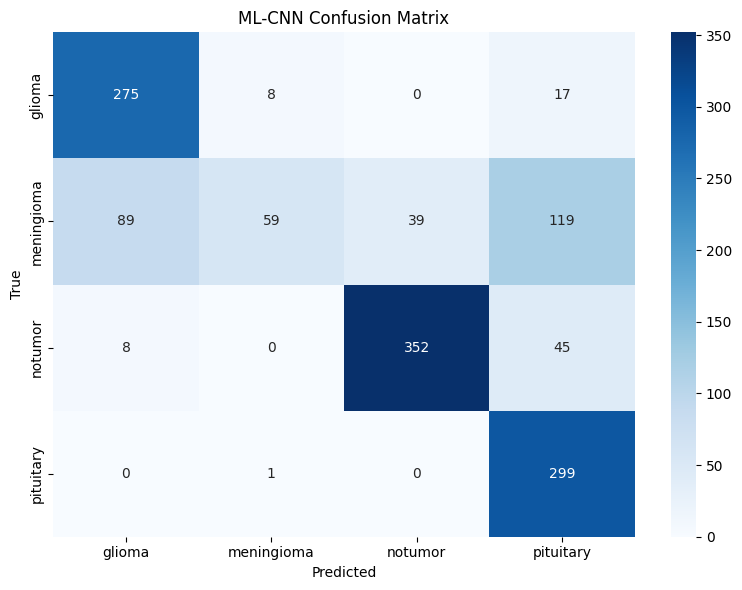

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ML-CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('mlcnn_confusion_matrix.png', dpi=300)
plt.show()

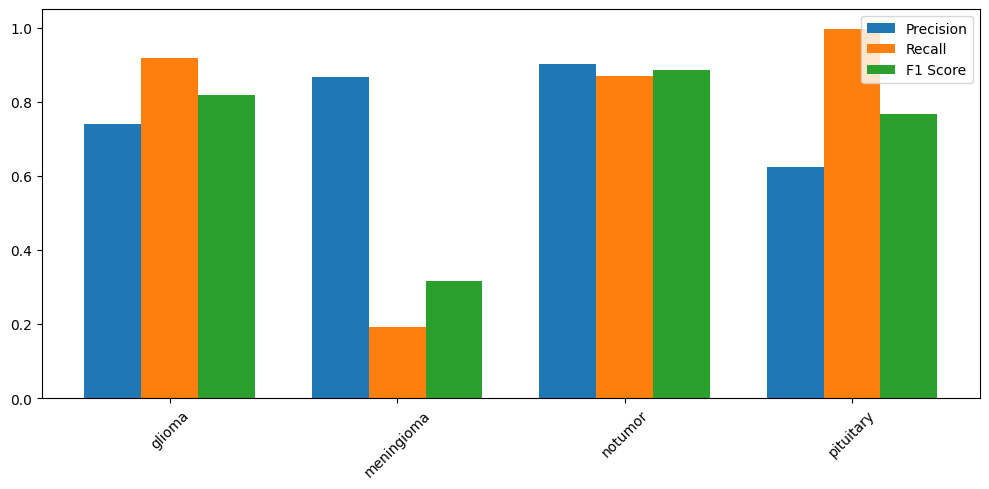

In [21]:
# Precision, Recall, F1
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred, average=None)
x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names, rotation=45)
plt.ylim([0, 1.05])
plt.legend()
plt.tight_layout()
plt.savefig('mlcnn_performance_metrics.png', dpi=300)
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib.ticker import MaxNLocator


In [23]:

# Load training log
df = pd.read_csv("adagrad-logs/mlcnn_training_log.csv")


/tmp/ipykernel_3334/3179076037.py:18: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_3334/3179076037.py:19: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



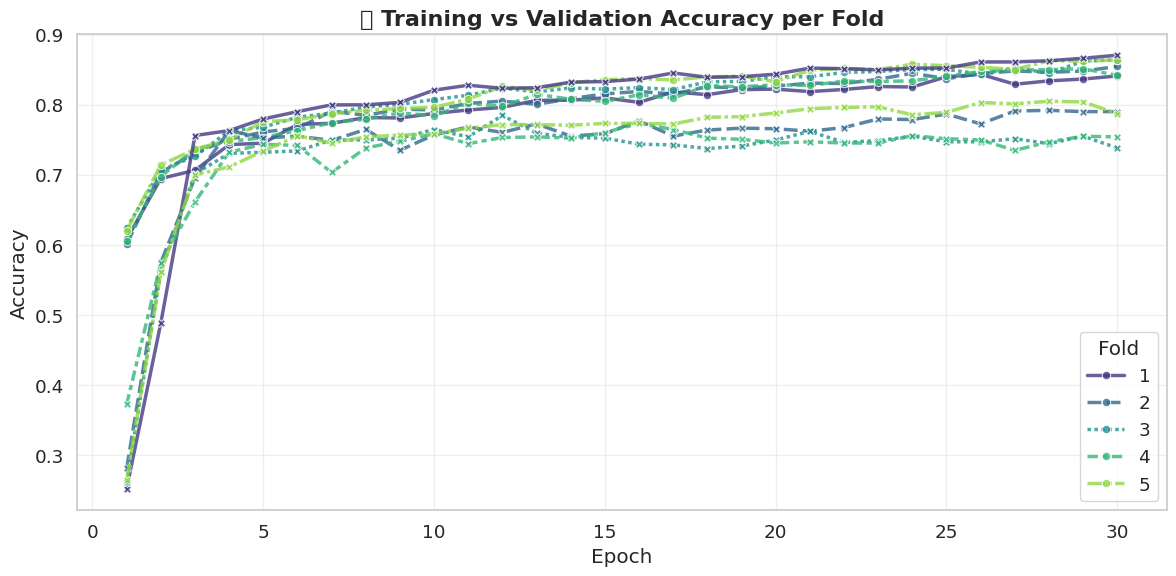

: 

In [ ]:

# Seaborn theme
sns.set_theme(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("viridis", n_colors=df['Fold'].nunique())

# -------------------------------
# 1️⃣ Accuracy and Loss Trends per Fold
# -------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Epoch", y="TrainAcc", hue="Fold", style="Fold",
             palette=palette, lw=2.5, marker="o", alpha=0.8)
sns.lineplot(data=df, x="Epoch", y="ValAcc", hue="Fold", style="Fold",
             palette=palette, lw=2.5, marker="X", alpha=0.8, legend=False)
plt.title("📈 Training vs Validation Accuracy per Fold", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(title="Fold", loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("adagrad-logs/accuracy_per_fold.png", dpi=400)
plt.show()


/tmp/ipykernel_3334/2385203875.py:13: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3334/2385203875.py:14: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("adagrad-logs/loss_per_fold.png", dpi=400)
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


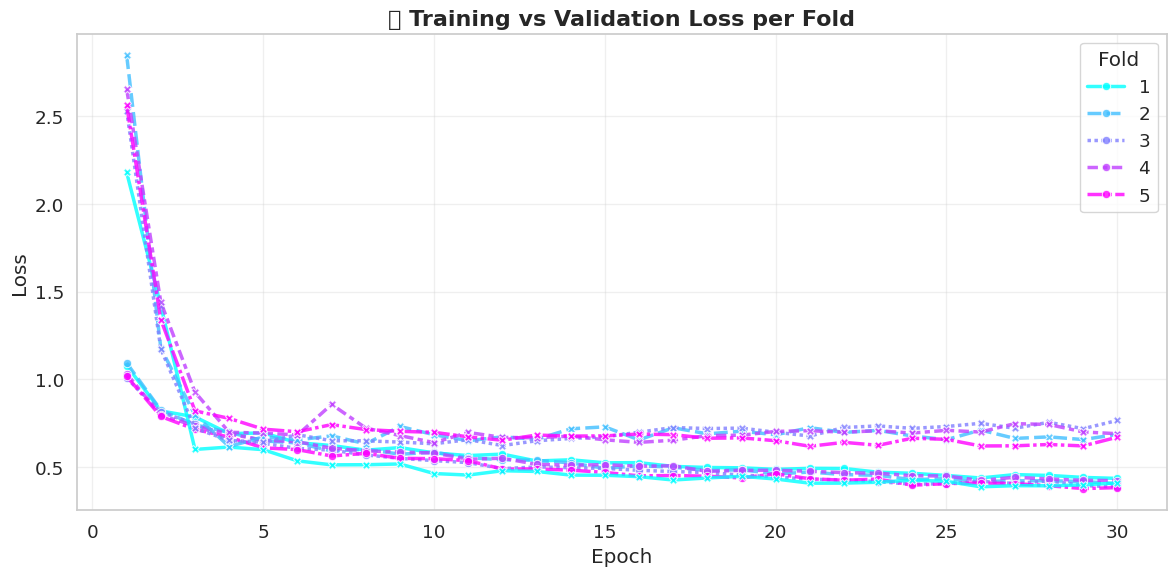

In [26]:

# -------------------------------
# 2️⃣ Train vs Validation Loss per Fold
# -------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Epoch", y="TrainLoss", hue="Fold", style="Fold",
             lw=2.5, palette="cool", marker="o", alpha=0.8)
sns.lineplot(data=df, x="Epoch", y="ValLoss", hue="Fold", style="Fold",
             lw=2.5, palette="cool", marker="X", alpha=0.8, legend=False)
plt.title("📉 Training vs Validation Loss per Fold", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("adagrad-logs/loss_per_fold.png", dpi=400)
plt.show()



/tmp/ipykernel_3334/752218817.py:14: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3334/752218817.py:15: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.savefig("adagrad-logs/mean_accuracy_trend.png", dpi=400)
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


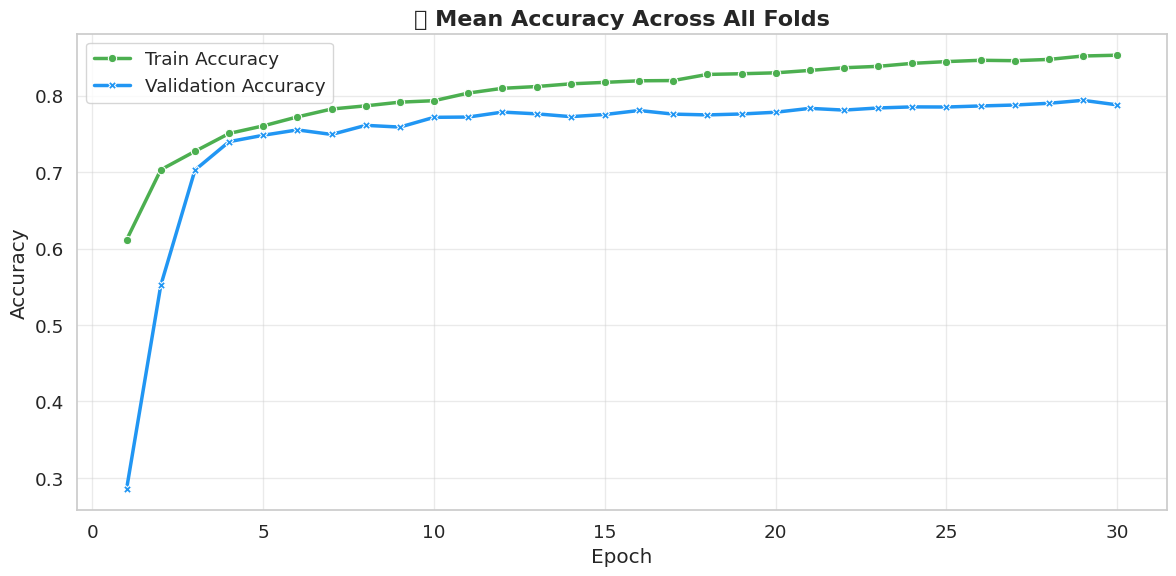

In [27]:

# -------------------------------
# 3️⃣ Average Metrics Across Folds
# -------------------------------
avg_df = df.groupby("Epoch")[["TrainAcc", "ValAcc", "TrainLoss", "ValLoss"]].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x="Epoch", y="TrainAcc", data=avg_df, marker="o", lw=2.5, label="Train Accuracy", color="#4CAF50")
sns.lineplot(x="Epoch", y="ValAcc", data=avg_df, marker="X", lw=2.5, label="Validation Accuracy", color="#2196F3")
plt.title("🌈 Mean Accuracy Across All Folds", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("adagrad-logs/mean_accuracy_trend.png", dpi=400)
plt.show()



/tmp/ipykernel_3334/133459821.py:10: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3334/133459821.py:11: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig("adagrad-logs/epoch_time_per_fold.png", dpi=400)
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


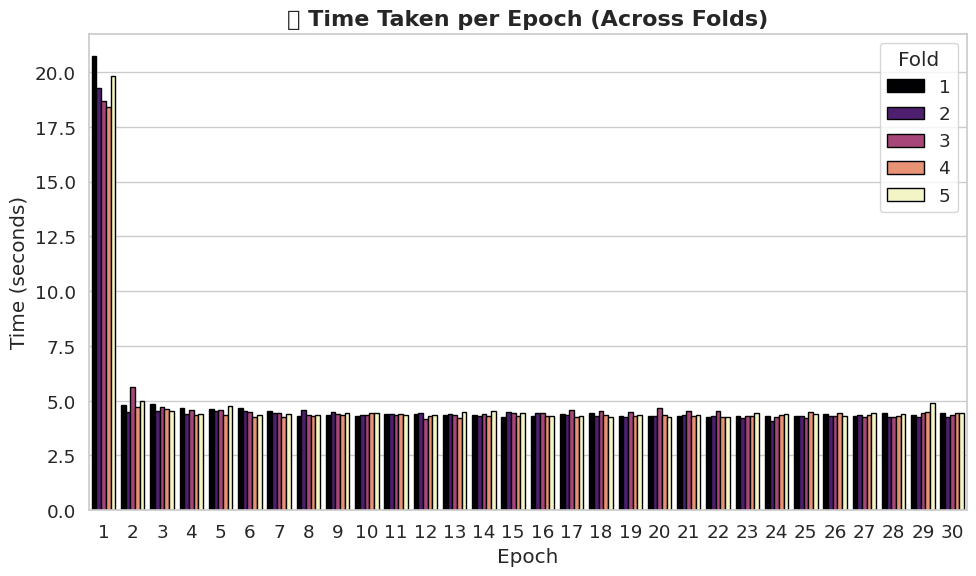

In [28]:
# -------------------------------
# 4️⃣ Epoch Time per Fold (Efficiency)
# -------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Epoch", y="TimeSec", hue="Fold", palette="magma", edgecolor="black")
plt.title("⏱️ Time Taken per Epoch (Across Folds)", fontsize=16, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.legend(title="Fold")
plt.tight_layout()
plt.savefig("adagrad-logs/epoch_time_per_fold.png", dpi=400)
plt.show()


/tmp/ipykernel_3334/2100180153.py:8: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3334/2100180153.py:9: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("adagrad-logs/metrics_correlation_heatmap.png", dpi=400)
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


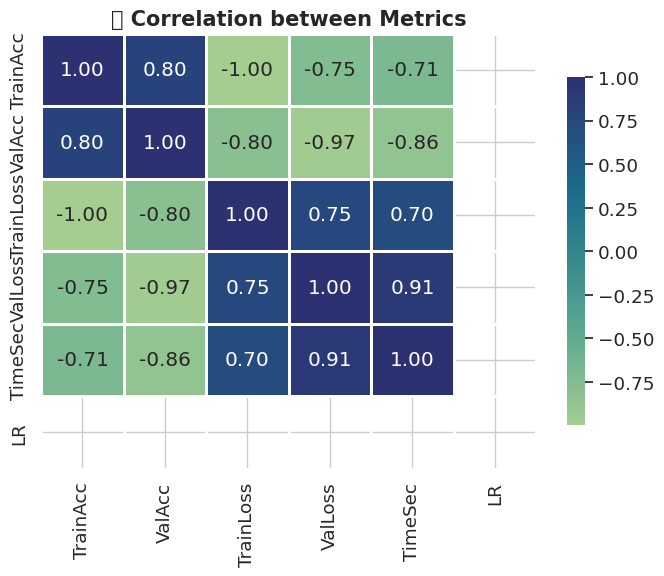

In [30]:

# -------------------------------
# 5️⃣ Correlation Heatmap
# -------------------------------
corr = df[["TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "TimeSec", "LR"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f", linewidths=1, cbar_kws={'shrink': 0.8})
plt.title("🔍 Correlation between Metrics", fontsize=15, weight='bold')
plt.tight_layout()
plt.savefig("adagrad-logs/metrics_correlation_heatmap.png", dpi=400)
plt.show()


In [33]:

# -------------------------------
# 6️⃣ Interactive Plotly Visualization (optional)
# -------------------------------
try:
    fig = px.line(df, x="Epoch", y="ValAcc", color="Fold",
                  title="✨ Interactive Validation Accuracy Across Folds",
                  markers=True, color_discrete_sequence=px.colors.sequential.Viridis)
    fig.update_traces(line=dict(width=3))
    fig.update_layout(template="plotly_white", title_x=0.5)
    fig.write_html("adagrad-logs/interactive_val_accuracy.html")
    fig.show()
    print("✅ Interactive visualization saved: logs/interactive_val_accuracy.html")
except Exception as e:
    print("Plotly visualization skipped:", e)


✅ Interactive visualization saved: logs/interactive_val_accuracy.html


In [34]:

# -------------------------------
# 🏁 Summary Metrics
# -------------------------------
summary = df.groupby("Fold")[["TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "TimeSec"]].agg(['mean', 'std'])
print("\n📊 Summary Metrics per Fold:")
print(summary)


📊 Summary Metrics per Fold:
      TrainAcc              ValAcc           TrainLoss             ValLoss  \
          mean       std      mean       std      mean       std      mean   
Fold                                                                         
1     0.793171  0.051335  0.799125  0.124305  0.567082  0.138888  0.552199   
2     0.801102  0.052648  0.742607  0.095756  0.548495  0.145887  0.775602   
3     0.810452  0.051685  0.724898  0.094896  0.523299  0.138802  0.771445   
4     0.798869  0.052591  0.726853  0.076468  0.550100  0.132154  0.795058   
5     0.813545  0.053723  0.748365  0.102630  0.515556  0.139256  0.763196   

                 TimeSec            
           std      mean       std  
Fold                                
1     0.358653  4.957412  2.982124  
2     0.402627  4.866883  2.721425  
3     0.345756  4.934586  2.612799  
4     0.380117  4.825263  2.563934  
5     0.363199  4.947584  2.816797  


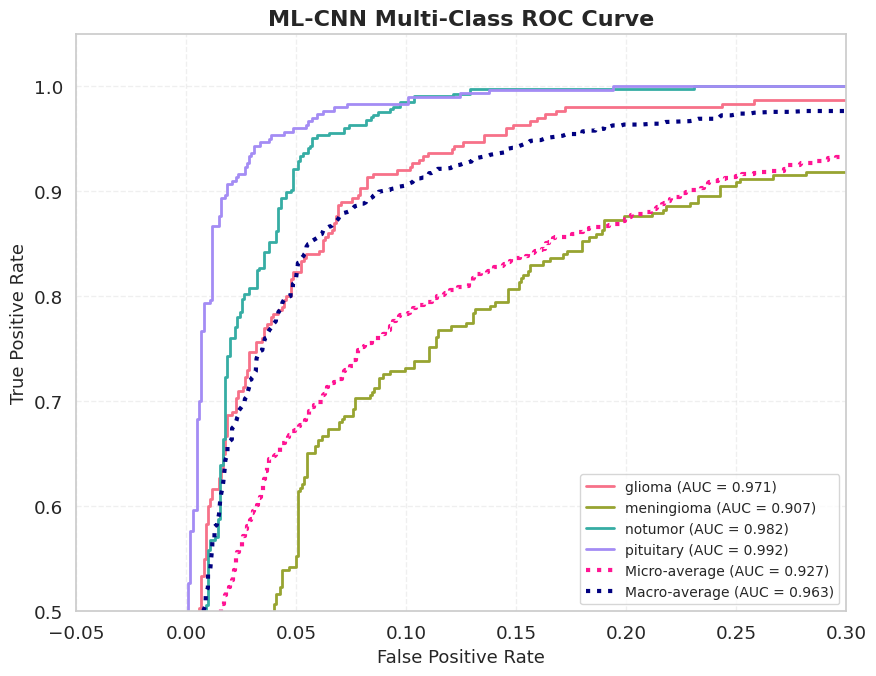

✅ Saved: ml_cnn_multiclass_roc.png


In [35]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc(y_true, y_pred_probs, class_names, model_name="ML-CNN"):
    # Binarize true labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ==== PLOT ====
    plt.figure(figsize=(9,7))
    colors = sns.color_palette("husl", n_classes)
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"],
             label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
             color="deeppink", linestyle=':', linewidth=3)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
             color="navy", linestyle=':', linewidth=3)
    plt.plot([0,1], [0,1], 'k--', lw=1.2)
    plt.xlim([-0.05, 0.3])
    plt.ylim([0.5, 1.05])
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title(f"{model_name} Multi-Class ROC Curve", fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10, frameon=True)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    filename = f"{model_name.lower().replace('-','_')}_multiclass_roc.png"
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")
plot_multiclass_roc(y_test_enc, y_pred_probs, class_names, model_name="ML-CNN") 

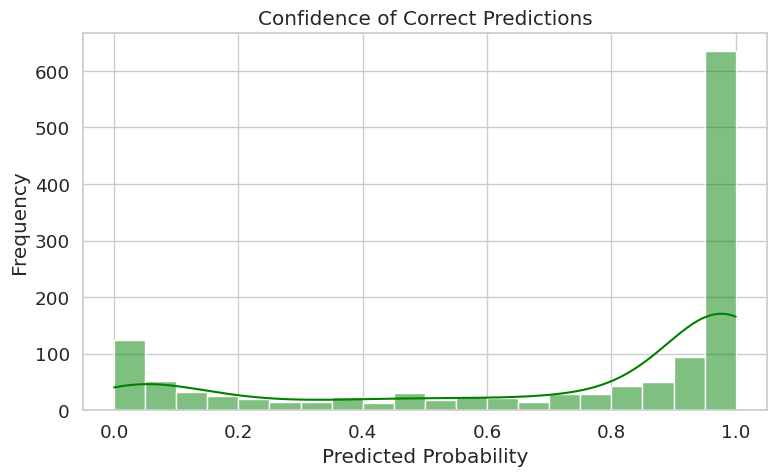

In [37]:
correct_probs = [y_pred_probs[i][y_test_enc[i]] for i in range(len(y_test_enc))]
plt.figure(figsize=(8,5))
sns.histplot(correct_probs, bins=20, kde=True, color='green')
plt.title('Confidence of Correct Predictions')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


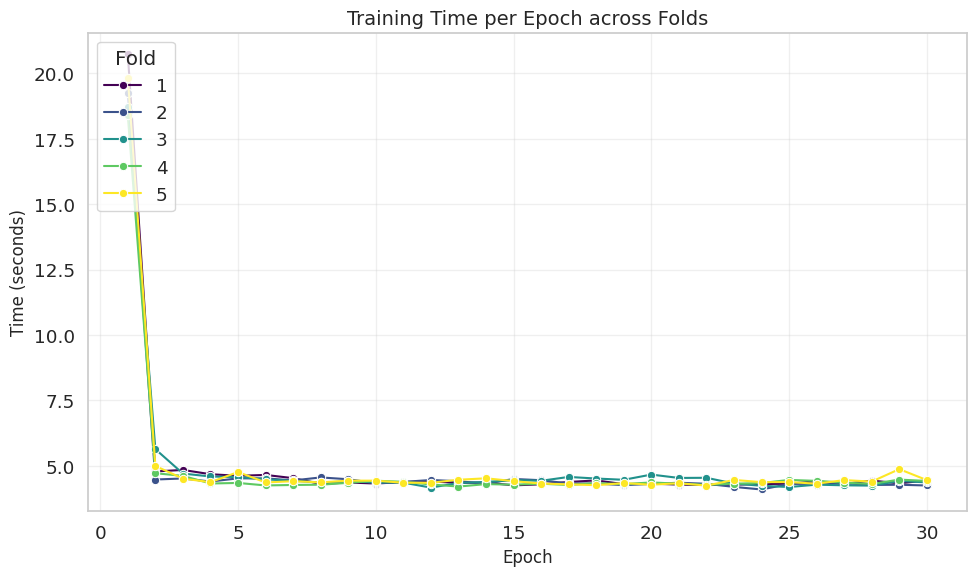

In [39]:
folds = df["Fold"]
epochs = df["Epoch"]
times = df["TimeSec"]

# Plot training time per epoch across folds
plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs, y=times, hue=folds, marker="o", palette="viridis")
plt.title("Training Time per Epoch across Folds", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)
plt.legend(title="Fold", loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("adagrad-logs/epoch_time_plot.png")
plt.show()